In [1]:
import sys
!{sys.executable} -m pip install torch torchvision --quiet

In [2]:
import torch
print("Torch verzija:", torch.__version__)
print("CUDA dostupna:", torch.cuda.is_available())
print("Broj CPU cores:", torch.get_num_threads())

Torch verzija: 2.12.1+cu130
CUDA dostupna: False
Broj CPU cores: 1


In [3]:
!free -h
import torch
print("Broj CPU cores:", torch.get_num_threads())

               total        used        free      shared  buff/cache   available
Mem:           7.8Gi       1.1Gi       4.8Gi       3.0Mi       1.8Gi       6.2Gi
Swap:          7.8Gi       168Mi       7.6Gi
Broj CPU cores: 1


In [4]:
torch.set_num_threads(2)
print("Broj CPU cores nakon postavke:", torch.get_num_threads())

Broj CPU cores nakon postavke: 2


In [5]:
from torchvision import models, transforms
import torch.nn as nn

resnet = models.resnet18(weights="IMAGENET1K_V1")
resnet.fc = nn.Identity()  # uklanja klasifikacijski sloj, output = 512-dim vektor
resnet.eval()

print("Model učitan, broj parametara:", sum(p.numel() for p in resnet.parameters()))

100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


Model učitan, broj parametara: 11176512


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transform definiran.")

Transform definiran.


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("movie_genre_metadata_clean.csv")
genre_matrix = np.load("genre_matrix.npy")

print(df.shape, genre_matrix.shape)
print(df[["id", "title"]].head())

(3985, 19) (3985, 19)
        id                                          title
0   937249                                     57 Seconds
1   575264  Mission: Impossible - Dead Reckoning Part One
2   299054                                    Expend4bles
3   678512                               Sound of Freedom
4  1151534                                        Nowhere


In [8]:
import os

missing = [str(id_) for id_ in df["id"] if not os.path.exists(f"posters/{id_}.jpg")]
print(f"Broj nedostajućih slika: {len(missing)}")
if missing:
    print(missing[:10])

Broj nedostajućih slika: 0


In [9]:
from PIL import Image
import torch

def extract_features(image_path, model, transform):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)
    with torch.no_grad():
        features = model(img_tensor)
    return features.squeeze().numpy()

test_id = df["id"].iloc[0]
test_features = extract_features(f"posters/{test_id}.jpg", resnet, transform)
print("Shape feature vektora:", test_features.shape)

Shape feature vektora: (512,)


In [10]:
import time

start = time.time()
for i in range(10):
    img_id = df["id"].iloc[i]
    _ = extract_features(f"posters/{img_id}.jpg", resnet, transform)
elapsed = time.time() - start

print(f"Vrijeme za 10 slika: {elapsed:.2f}s")
print(f"Procjena za svih {len(df)} slika: {elapsed/10*len(df)/60:.1f} minuta")

Vrijeme za 10 slika: 3.34s
Procjena za svih 3985 slika: 22.2 minuta


In [11]:
import time

features_list = []
ids_list = []
CHECKPOINT_EVERY = 500

start = time.time()

for i, row in enumerate(df.itertuples()):
    img_path = f"posters/{row.id}.jpg"
    feat = extract_features(img_path, resnet, transform)
    features_list.append(feat)
    ids_list.append(row.id)
    
    if (i + 1) % CHECKPOINT_EVERY == 0:
        elapsed = time.time() - start
        print(f"Obrađeno {i+1}/{len(df)} ({elapsed/60:.1f} min)...")
        # checkpoint spremanje
        np.save("features_checkpoint.npy", np.array(features_list))
        np.save("ids_checkpoint.npy", np.array(ids_list))

print(f"\nGotovo! Ukupno vrijeme: {(time.time()-start)/60:.1f} minuta")

features_array = np.array(features_list)
ids_array = np.array(ids_list)
print("Shape feature matrice:", features_array.shape)

Obrađeno 500/3985 (2.0 min)...
Obrađeno 1000/3985 (4.0 min)...
Obrađeno 1500/3985 (6.0 min)...
Obrađeno 2000/3985 (8.1 min)...
Obrađeno 2500/3985 (10.2 min)...
Obrađeno 3000/3985 (12.1 min)...
Obrađeno 3500/3985 (14.1 min)...

Gotovo! Ukupno vrijeme: 16.1 minuta
Shape feature matrice: (3985, 512)


In [12]:
print("Provjera redoslijeda:", np.array_equal(ids_array, df["id"].values))

Provjera redoslijeda: True


In [13]:
np.save("poster_features_resnet18.npy", features_array)
np.save("poster_feature_ids.npy", ids_array)

import os
os.remove("features_checkpoint.npy")
os.remove("ids_checkpoint.npy")

print("Finalni feature vektori spremljeni.")

Finalni feature vektori spremljeni.


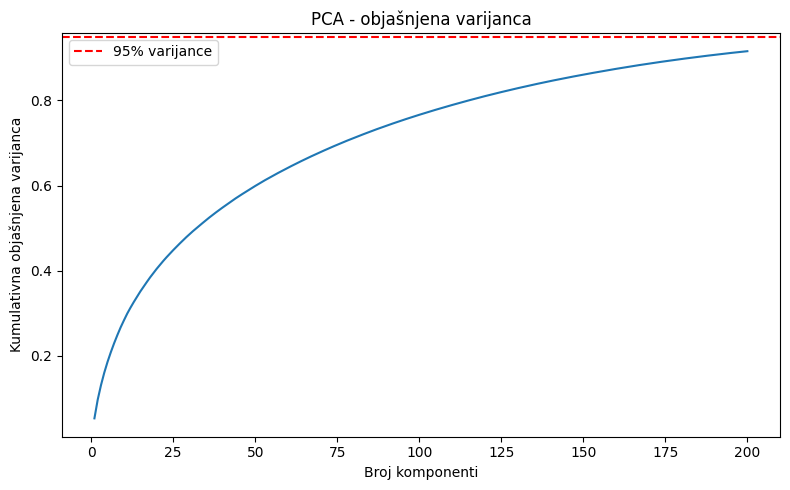

Varijanca s 50 komponenti: 0.599
Varijanca s 100 komponenti: 0.766
Varijanca s 150 komponenti: 0.861
Varijanca s 200 komponenti: 0.916


In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA(n_components=200, random_state=42)
pca_full.fit(features_array)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 201), cumulative_variance)
plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativna objašnjena varijanca")
plt.title("PCA - objašnjena varijanca")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varijance')
plt.legend()
plt.tight_layout()
plt.savefig("pca_variance.png")
plt.show()

print(f"Varijanca s 50 komponenti: {cumulative_variance[49]:.3f}")
print(f"Varijanca s 100 komponenti: {cumulative_variance[99]:.3f}")
print(f"Varijanca s 150 komponenti: {cumulative_variance[149]:.3f}")
print(f"Varijanca s 200 komponenti: {cumulative_variance[199]:.3f}")

In [15]:
pca = PCA(n_components=150, random_state=42)
features_pca = pca.fit_transform(features_array)

print("Shape prije PCA:", features_array.shape)
print("Shape nakon PCA:", features_pca.shape)
print(f"Objašnjena varijanca: {pca.explained_variance_ratio_.sum():.3f}")

Shape prije PCA: (3985, 512)
Shape nakon PCA: (3985, 150)
Objašnjena varijanca: 0.860
